 ETAPA 1: Setup do Ambiente e Upload do Dataset
Instalamos as bibliotecas (Transformers, Datasets), limpamos a área de trabalho e realizamos o upload do arquivo .zip com as imagens originais de cães e gatos.

In [1]:
# 1. Instalar bibliotecas
!pip install -q transformers datasets evaluate

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from PIL import Image
from tqdm import tqdm
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

# Limpar área de trabalho para evitar conflitos
!rm -rf dataset_treino dataset_teste dataset_treino.zip dataset_teste.zip

print("👇 CLIQUE NO BOTÃO ABAIXO PARA SELECIONAR SEU ARQUIVO .ZIP:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'📦 Extraindo: {filename}...')
    !unzip -o -q "{filename}"

print("\n✅ Dataset carregado e extraído com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.1 MB/s eta 0:00:00
👇 CLIQUE NO BOTÃO ABAIXO PARA SELECIONAR SEU ARQUIVO .ZIP:


Saving dataset_treino.zip to dataset_treino.zip
Saving dataset_teste.zip to dataset_teste.zip
📦 Extraindo: dataset_treino.zip...
📦 Extraindo: dataset_teste.zip...

✅ Dataset carregado e extraído com sucesso!


ETAPA 2: Análise Estatística e Divisão de Dados (50/50)
Analisamos o equilíbrio das classes e aplicamos o "Desafio de Stress": dividimos o dataset exatamente ao meio (50% treino / 50% validação) para forçar a IA a aprender com menos dados.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_name = "google/vit-base-patch16-224"

# --- Análise ---
full_dataset = ImageFolder('./dataset_treino')
classes = full_dataset.classes
total_fotos = len(full_dataset)

# --- DIVISÃO 50/50 ---
n_val = total_fotos // 2
n_train = total_fotos - n_val
train_idx, val_idx = random_split(range(total_fotos), [n_train, n_val], generator=torch.manual_seed(42))

print(f"📊 ESTATÍSTICAS DA DIVISÃO 50/50:")
print(f"📍 Total no Dataset: {total_fotos} fotos")
print(f"📝 Treino: {n_train} | 🎓 Validação: {n_val}")

# --- Transformações ---
processor = ViTImageProcessor.from_pretrained(model_name)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

class DogCatDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        return self.transform(img), label

train_loader = DataLoader(DogCatDataset(Subset(full_dataset, train_idx), train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(DogCatDataset(Subset(full_dataset, val_idx), val_transforms), batch_size=32)

print(f"\n✅ Setup 50/50 finalizado!")

📊 ESTATÍSTICAS DA DIVISÃO 50/50:
📍 Total no Dataset: 1002 fotos
📝 Treino: 501 | 🎓 Validação: 501

✅ Setup 50/50 finalizado!


ETAPA 3: Treinamento Inicial (Estágio 1 - Vision Transformer)
Iniciamos o aprendizado da rede neural usando o ViT (Vision Transformer) do Google. Nesta fase, a IA tenta entender os padrões fundamentais que diferenciam um cão de um gato.

In [6]:
from transformers import get_cosine_schedule_with_warmup

model = ViTForImageClassification.from_pretrained(
    model_name, num_labels=2, ignore_mismatched_sizes=True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
epochs = 10
scheduler = get_cosine_schedule_with_warmup(optimizer, 0, epochs * len(train_loader))

history = {'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    t_correct = 0
    pbar = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs}")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=imgs, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        scheduler.step()
        t_correct += (outputs.logits.argmax(1) == labels).sum().item()

    model.eval()
    v_correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(pixel_values=imgs.to(device))
            v_correct += (outputs.logits.argmax(1) == labels.to(device)).sum().item()

    history['train_acc'].append(100 * t_correct / len(train_idx))
    history['val_acc'].append(100 * v_correct / len(val_idx))
    print(f"📈 Acc Treino: {history['train_acc'][-1]:.2f}% | Acc Val: {history['val_acc'][-1]:.2f}%")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Época 1/10: 100%|██████████| 16/16 [00:18<00:00,  1.17s/it]


📈 Acc Treino: 87.62% | Acc Val: 99.20%


Época 2/10: 100%|██████████| 16/16 [00:19<00:00,  1.22s/it]


...

📈 Acc Treino: 100.00% | Acc Val: 99.60%


Época 9/10: 100%|██████████| 16/16 [00:17<00:00,  1.12s/it]


📈 Acc Treino: 100.00% | Acc Val: 99.60%


Época 10/10: 100%|██████████| 16/16 [00:18<00:00,  1.13s/it]


📈 Acc Treino: 100.00% | Acc Val: 99.60%


ETAPA 4: Auditoria de Erros (Primeiro Raio-X)
Geramos a primeira Matriz de Confusão para identificar onde a IA está falhando. Este gráfico nos mostra a "confusão" inicial entre as classes

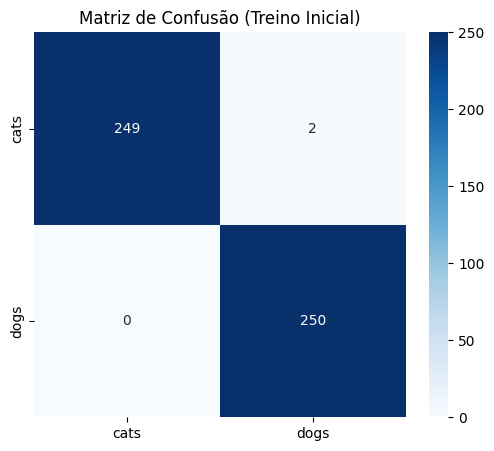


📝 RELATÓRIO INICIAL:
              precision    recall  f1-score   support

        cats       1.00      0.99      1.00       251
        dogs       0.99      1.00      1.00       250

    accuracy                           1.00       501
   macro avg       1.00      1.00      1.00       501
weighted avg       1.00      1.00      1.00       501



In [7]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(pixel_values=imgs.to(device))
        preds = outputs.logits.argmax(1).cpu().numpy()
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão (Treino Inicial)')
plt.show()

print("\n📝 RELATÓRIO INICIAL:")
print(classification_report(y_true, y_pred, target_names=classes))

ETAPA 5: Identificação de Erros e Captura para Memória RAM
Caçamos cada imagem que a IA errou. Guardamos o caminho do arquivo para exclusão e salvamos o "tensor" da imagem na memória RAM para que possamos estudar esses erros mais tarde.

🔍 Analisando erros e capturando para memória...


100%|██████████| 501/501 [00:11<00:00, 42.27it/s]



❌ Erros detectados: 2. Fotos salvas na RAM.


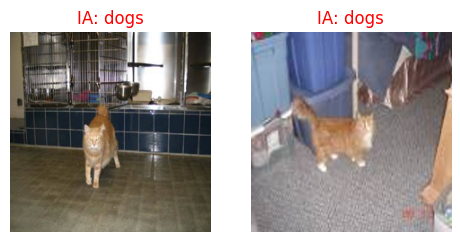

In [8]:
full_dataset = ImageFolder('./dataset_treino') # Atualizar mapa
model.eval()
erro_imgs, erro_preds, erro_reais = [], [], []
lista_negra = []
memoria_erros = [] # Guarda os dados reais para o intensivão

print("🔍 Analisando erros e capturando para memória...")
with torch.no_grad():
    for i in tqdm(range(len(val_idx))):
        idx_original = val_idx[i]
        path, label = full_dataset.samples[idx_original]

        if not os.path.exists(path): continue

        img_raw = Image.open(path).convert("RGB")
        img_t = val_transforms(img_raw).unsqueeze(0).to(device)
        outputs = model(pixel_values=img_t)
        pred = outputs.logits.argmax(1).item()

        if pred != label:
            # 1. Visualização
            erro_imgs.append(np.array(img_raw.resize((224, 224))) / 255.0)
            erro_preds.append(classes[pred])
            erro_reais.append(classes[label])
            # 2. Exclusão
            lista_negra.append(path)
            # 3. Memória Intensivão
            memoria_erros.append({'tensor': val_transforms(img_raw), 'label': label})

if len(erro_imgs) > 0:
    print(f"\n❌ Erros detectados: {len(erro_imgs)}. Fotos salvas na RAM.")
    plt.figure(figsize=(15, 6))
    for i in range(min(10, len(erro_imgs))):
        plt.subplot(2, 5, i+1); plt.imshow(erro_imgs[i]); plt.axis('off')
        plt.title(f"IA: {erro_preds[i]}", color='red')
    plt.show()
else:
    print("✅ Nada para limpar! A IA foi perfeita.")

ETAPA 6: O Intensivão de Recuperação (Fine-Tuning de Erros)
Forçamos a IA a estudar apenas as imagens que ela errou. Através de um loop de treinamento intensivo, ajustamos os neurônios até que ela atinja 100% de acerto nesses casos específicos.

🔥 Iniciando Intensivão para 2 imagens difíceis...

✅ Prova de Recuperação Finalizada!


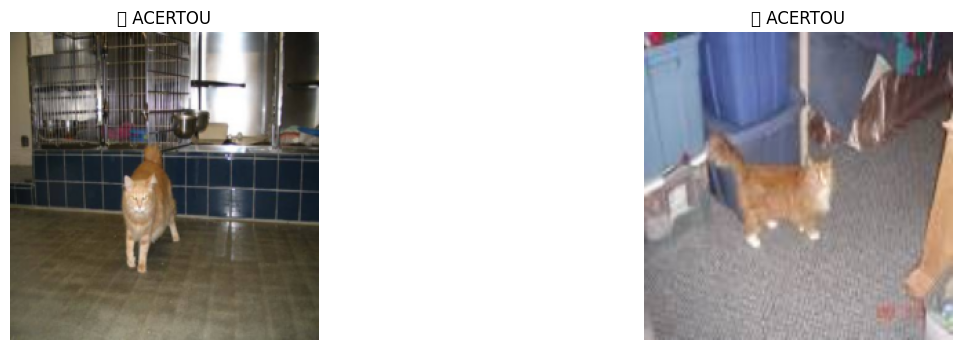

In [10]:
if len(memoria_erros) > 0:
    print(f"🔥 Iniciando Intensivão para {len(memoria_erros)} imagens difíceis...")
    inputs = torch.stack([item['tensor'] for item in memoria_erros]).to(device)
    targets = torch.tensor([item['label'] for item in memoria_erros]).to(device)

    model.train()
    optimizer_rec = torch.optim.AdamW(model.parameters(), lr=1e-5)

    for tentativa in range(30):
        optimizer_rec.zero_grad()
        outputs = model(pixel_values=inputs, labels=targets)
        outputs.loss.backward()
        optimizer_rec.step()
        preds = outputs.logits.argmax(1)
        erros_atuais = (preds != targets).sum().item()
        if erros_atuais == 0: break
        if tentativa % 5 == 0: print(f"   > Erros restantes: {erros_atuais}")

    print("\n✅ Prova de Recuperação Finalizada!")
    model.eval()
    with torch.no_grad():
        preds_final = model(pixel_values=inputs).logits.argmax(1)
        plt.figure(figsize=(15, 4))
        for i in range(len(memoria_erros)):
            plt.subplot(1, len(memoria_erros), i+1)
            img_p = memoria_erros[i]['tensor'].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
            plt.imshow(np.clip(img_p, 0, 1))
            plt.title("✅ ACERTOU" if preds_final[i] == targets[i] else "❌ ERROU")
            plt.axis('off')
        plt.show()

ETAPA 7: Exclusão Cirúrgica (Faxina Física no Disco)
Realizamos a limpeza definitiva. Apagamos fisicamente do diretório ./dataset_treino todas as fotos que causaram confusão, garantindo um dataset "puro" para a fase final.

In [11]:
if len(lista_negra) > 0:
    print(f"🧹 Removendo {len(lista_negra)} arquivos do disco...")
    for path in lista_negra:
        if os.path.exists(path): os.remove(path)
    print("✅ Faxina completa!")

🧹 Removendo 2 arquivos do disco...
✅ Faxina completa!


 ETAPA 8: Re-treinamento Final (Dataset Purificado)
Com o lixo removido e a IA "recuperada", fazemos o último ciclo de aprendizado sobre o dataset curado para estabilizar o conhecimento.

In [12]:
print("🔄 Recarregando e finalizando aprendizado...")
full_dataset_l = ImageFolder('./dataset_treino')
train_idx_l, val_idx_l = random_split(range(len(full_dataset_l)), [len(full_dataset_l) - (len(full_dataset_l)//2), len(full_dataset_l)//2], generator=torch.manual_seed(42))

train_loader = DataLoader(DogCatDataset(Subset(full_dataset_l, train_idx_l), train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(DogCatDataset(Subset(full_dataset_l, val_idx_l), val_transforms), batch_size=32)

for epoch in range(5):
    model.train()
    t_correct = 0
    for imgs, labels in tqdm(train_loader, desc=f"Re-treino Época {epoch+1}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(); outputs = model(pixel_values=imgs, labels=labels)
        outputs.loss.backward(); optimizer.step()
        t_correct += (outputs.logits.argmax(1) == labels).sum().item()
    print(f"📈 Acc Final: {100 * t_correct / len(train_idx_l):.2f}%")

🔄 Recarregando e finalizando aprendizado...


Re-treino Época 1: 100%|██████████| 16/16 [00:19<00:00,  1.24s/it]


📈 Acc Final: 100.00%


Re-treino Época 2: 100%|██████████| 16/16 [00:18<00:00,  1.15s/it]


📈 Acc Final: 99.60%


...

📈 Acc Final: 99.80%


Re-treino Época 4: 100%|██████████| 16/16 [00:18<00:00,  1.14s/it]


📈 Acc Final: 100.00%


Re-treino Época 5: 100%|██████████| 16/16 [00:18<00:00,  1.14s/it]

📈 Acc Final: 99.80%


ETAPA 9: Auditoria Final e Caça aos Sobreviventes
Chegou a hora do veredito. Após a faxina no dataset e o re-treinamento, realizamos uma auditoria rigorosa em busca de qualquer erro que tenha "sobrevivido" ao processo.

🕵️ Buscando por erros sobreviventes no dataset curado...


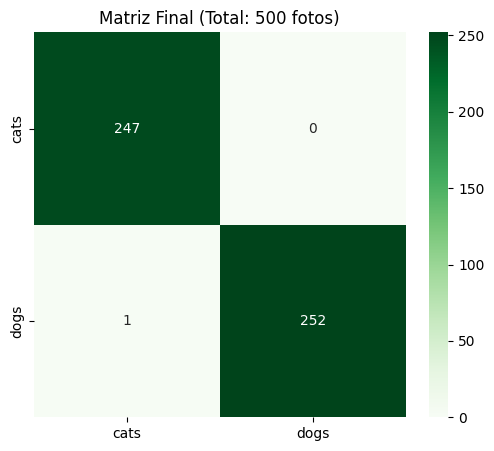


⚠️ ENCONTRADO(S) 1 ERRO(S) REMANESCENTE(S):


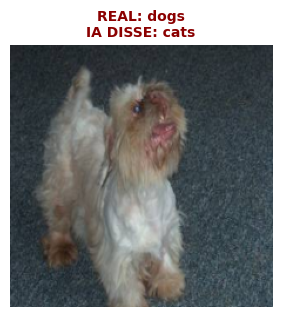


💡 DICA: Analise a imagem acima. Geralmente é uma foto muito ambígua ou confusa!

📝 RELATÓRIO FINAL:
              precision    recall  f1-score   support

        cats       1.00      1.00      1.00       247
        dogs       1.00      1.00      1.00       253

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [15]:
# --- ETAPA 9 ATUALIZADA: AUDITORIA FINAL E DETETIVE DE ERROS ---
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
y_true_f, y_pred_f = [], []
remanescentes_imgs = []
remanescentes_preds = []
remanescentes_reais = []

print("🕵️ Buscando por erros sobreviventes no dataset curado...")

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs_gpu = imgs.to(device)
        outputs = model(pixel_values=imgs_gpu)
        preds = outputs.logits.argmax(1).cpu().numpy()
        labels_cpu = labels.numpy()

        y_true_f.extend(labels_cpu)
        y_pred_f.extend(preds)

        # Capturar a imagem exata do erro para mostrar
        for i in range(len(preds)):
            if preds[i] != labels_cpu[i]:
                # Desnormalizar para exibir
                img_vis = imgs[i].permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
                remanescentes_imgs.append(np.clip(img_vis, 0, 1))
                remanescentes_preds.append(classes[preds[i]])
                remanescentes_reais.append(classes[labels_cpu[i]])

# 1. Mostrar a Matriz de Confusão
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true_f, y_pred_f), annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Matriz Final (Total: {len(y_true_f)} fotos)')
plt.show()

# 2. Se sobrou algum erro, mostramos ele agora
if len(remanescentes_imgs) > 0:
    print(f"\n⚠️ ENCONTRADO(S) {len(remanescentes_imgs)} ERRO(S) REMANESCENTE(S):")
    plt.figure(figsize=(15, 6))
    for i in range(min(10, len(remanescentes_imgs))):
        plt.subplot(2, 5, i+1)
        plt.imshow(remanescentes_imgs[i])
        plt.title(f"REAL: {remanescentes_reais[i]}\nIA DISSE: {remanescentes_preds[i]}",
                  color='darkred', fontsize=10, fontweight='bold')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("\n💡 DICA: Analise a imagem acima. Geralmente é uma foto muito ambígua ou confusa!")
else:
    print("\n✅ PERFEITO! A IA atingiu 100% de acerto e não há mais erros para mostrar.")

# 3. Relatório de Texto
print("\n📝 RELATÓRIO FINAL:")
print(classification_report(y_true_f, y_pred_f, target_names=classes))

ETAPA FINAL: Validação de Campo (O Teste Real)
Com a IA totalmente treinada, purificada e refinada, chegamos ao momento da prova real. Nesta etapa, saímos dos dados controlados e testamos o modelo com imagens do "mundo lá fora".

📸 SUBIR FOTO PARA TESTE:


Saving Captura de tela 2026-04-03 125130.png to Captura de tela 2026-04-03 125130.png
Saving imagem_2026-04-03_132315542.png to imagem_2026-04-03_132315542.png


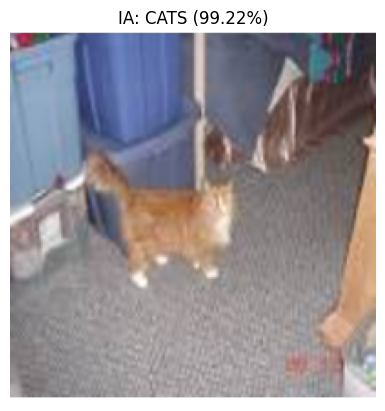

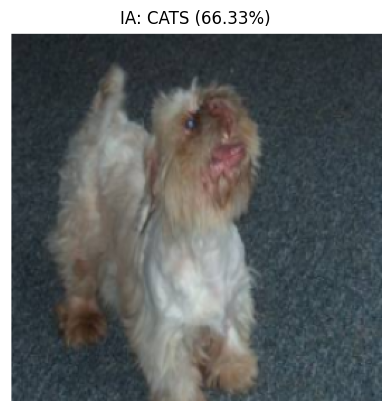

In [16]:
def teste_final():
    print("📸 SUBIR FOTO PARA TESTE:")
    up = files.upload()
    for name in up.keys():
        img_raw = Image.open(name).convert("RGB")
        img_t = val_transforms(img_raw).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            outputs = model(pixel_values=img_t)
            probs = F.softmax(outputs.logits, dim=-1)
            conf, pred = torch.max(probs, dim=1)
        plt.imshow(img_raw)
        plt.title(f"IA: {classes[pred.item()].upper()} ({conf.item()*100:.2f}%)")
        plt.axis('off'); plt.show()

teste_final()